In [1]:
# ============================
# Mount Google Drive
# ============================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# ============================
# Load the DataFrame
# ============================
import pandas as pd

file_path = "/content/drive/MyDrive/AI351ProjectTest/05-FinalCompilation/FinalCompiledDataset.csv"
df = pd.read_csv(file_path)

df.head()


,text,label,label_desc,translation,MetricX24_Raw,MetricX24_Scaled_BATAYAN,Flag
0,Normally I hate even thinking about this becau...,0,sadness,Karaniwan akong ayaw mag-isip tungkol dito dah...,0.180561,99.277754,0
1,"You are not alone, trust me. We all face our h...",0,sadness,"Hindi ka nag-iisa, maniwala ka sa akin. Lahat ...",0.221019,99.115925,0
2,i felt like talking too but i didn t know what...,0,sadness,Gusto kong magsalita rin pero hindi ko alam ku...,0.923421,96.306317,0
3,My brother is like my best friend. We are clos...,0,sadness,Ang kapatid ko ay parang pinakamahusay kong ka...,-0.688570,100.000000,0
4,i feel like nobody really care if i m gone eve...,0,sadness,Nararamdaman kong walang tunay na nag-aalala k...,1.094810,95.620761,0


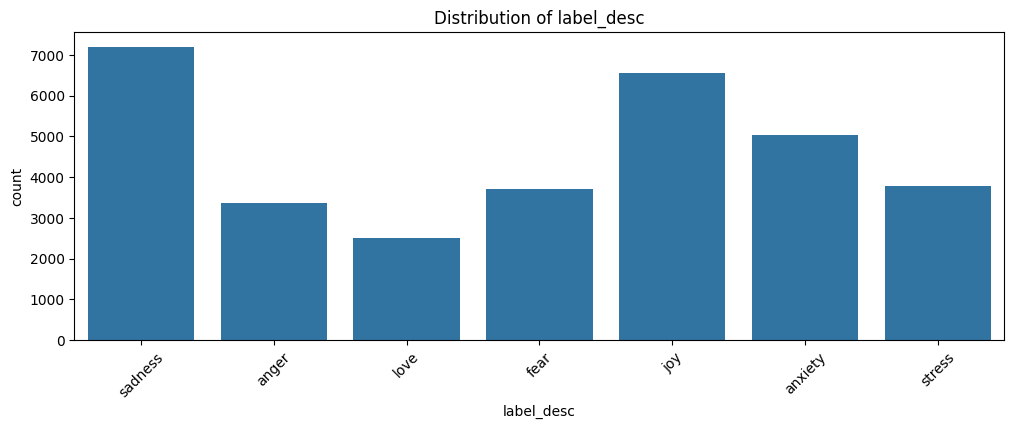

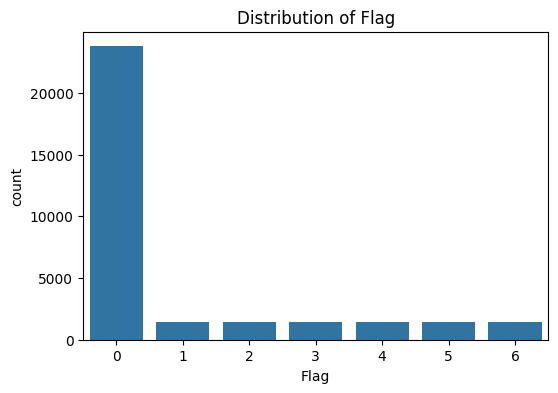

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
sns.countplot(data=df, x="label_desc")
plt.title("Distribution of label_desc")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Flag")
plt.title("Distribution of Flag")
plt.show()


In [8]:
df["stratify_key"] = df["label_desc"].astype(str) + "_" + df["Flag"].astype(str)
df["stratify_key"].value_counts()

,count
stratify_key,
sadness_0,6000
joy_0,5362
anxiety_0,3841
stress_0,2587
fear_0,2509
anger_0,2159
love_0,1304
sadness_1,200
joy_1,200


In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["stratify_key"],
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 25729
Test size: 6433


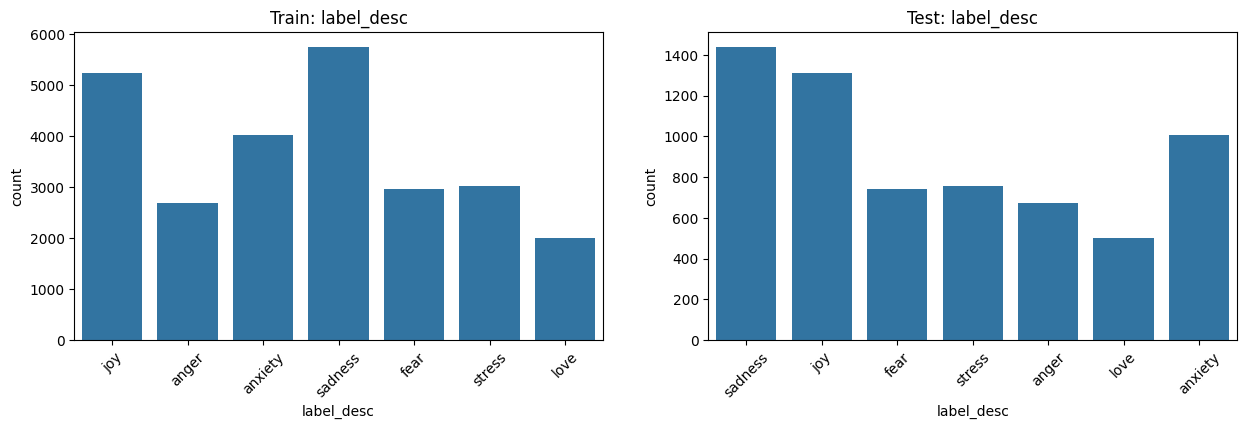

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15,4))

sns.countplot(data=train_df, x="label_desc", ax=axes[0])
axes[0].set_title("Train: label_desc")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=test_df, x="label_desc", ax=axes[1])
axes[1].set_title("Test: label_desc")
axes[1].tick_params(axis='x', rotation=45)

plt.show()

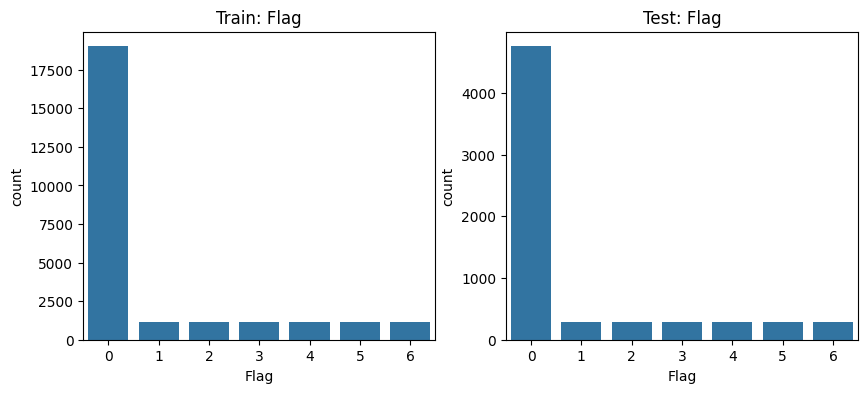

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(data=train_df, x="Flag", ax=axes[0])
axes[0].set_title("Train: Flag")

sns.countplot(data=test_df, x="Flag", ax=axes[1])
axes[1].set_title("Test: Flag")

plt.show()

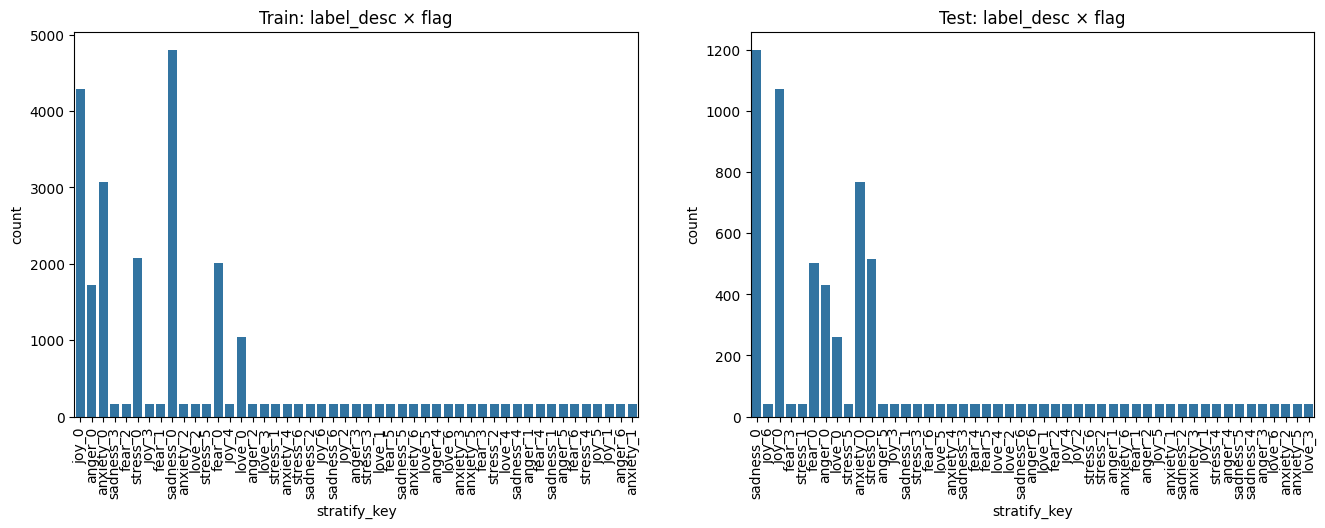

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.countplot(data=train_df, x="stratify_key", ax=axes[0])
axes[0].set_title("Train: label_desc × flag")
axes[0].tick_params(axis='x', rotation=90)

sns.countplot(data=test_df, x="stratify_key", ax=axes[1])
axes[1].set_title("Test: label_desc × flag")
axes[1].tick_params(axis='x', rotation=90)

plt.show()


In [14]:
import os

notebook_path = "/content/drive/MyDrive/AI351ProjectTest/07-TrainTestSplit/"

train_file_path = os.path.join(notebook_path, "train_data.csv")
test_file_path  = os.path.join(notebook_path, "test_data.csv")

train_df.to_csv(train_file_path, index=False)
test_df.to_csv(test_file_path, index=False)

print("Files saved:")
print(train_file_path)
print(test_file_path)


Files saved:
/content/drive/MyDrive/AI351ProjectTest/07-TrainTestSplit/train_data.csv
/content/drive/MyDrive/AI351ProjectTest/07-TrainTestSplit/test_data.csv
